In [ ]:
import numpy as np
import tensorflow as tf
import random
import os

os.environ['PYTHONHASHSEED'] = str(42)
os.environ['TF_DETERMINISTIC_OPS'] ='1'
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# 1. **Data Aquisition**

In [ ]:
rm -rf /content/*

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rifafathima20","key":"fbb21d27a5753bcb75c41123cf358df4"}'}

In [ ]:
!mkdir ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
#download datasets
!kaggle datasets download -d tawsifurrahman/covid19-radiography-database

Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database
License(s): copyright-authors
 96% 749M/778M [00:03<00:00, 115MB/s] 
100% 778M/778M [00:03<00:00, 210MB/s]


In [ ]:
#unzip
!unzip covid19-radiography-database.zip -d covid_radiography

Streaming output truncated to the last 5000 lines.
  inflating: covid_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-7921.png  
  inflating: covid_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-7922.png  
  inflating: covid_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-7923.png  
  inflating: covid_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-7924.png  
  inflating: covid_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-7925.png  
  inflating: covid_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-7926.png  
  inflating: covid_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-7927.png  
  inflating: covid_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-7928.png  
  inflating: covid_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-7929.png  
  inflating: covid_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-793.png  
  inflating: covid_radiography/COVID-19_

# 1. **Preprocessing**



1 .Install utilities & import libraries

In [ ]:
# ✅ Installing 'tree' to visualize folders (common viva question: "how did you verify dataset?")
!apt-get install tree > /dev/null

# ✅ Import required libs
import os, shutil, random, hashlib
from glob import glob
from tqdm import tqdm
import numpy as np
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True  # allows loading partially broken files

print("Environment Ready ✅")


Environment Ready ✅


2. Set data paths

In [ ]:
# Path to your unzipped radiography dataset
BASE_DIR = "/content/covid_radiography/COVID-19_Radiography_Dataset"

# Output dataset directory (clean + standardized)
OUT_DIR = "/content/processed_dataset"
os.makedirs(OUT_DIR, exist_ok=True)

print("Base Path:", BASE_DIR)
print("Output Path:", OUT_DIR)

Base Path: /content/covid_radiography/COVID-19_Radiography_Dataset
Output Path: /content/processed_dataset


3. Check folder structure

In [ ]:
!apt-get install tree
!tree -L 3 /content


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tree is already the newest version (2.0.2-1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.
/content
├── covid19-radiography-database.zip
├── covid_radiography
│   └── COVID-19_Radiography_Dataset
│       ├── COVID
│       ├── COVID.metadata.xlsx
│       ├── Lung_Opacity
│       ├── Lung_Opacity.metadata.xlsx
│       ├── Normal
│       ├── Normal.metadata.xlsx
│       ├── README.md.txt
│       ├── Viral Pneumonia
│       └── Viral Pneumonia.metadata.xlsx
└── processed_dataset

7 directories, 6 files


4. Count images in each class

In [ ]:
for cls in os.listdir(BASE_DIR):
    path = os.path.join(BASE_DIR, cls)
    if os.path.isdir(path):
        count = sum([len(files) for _,_,files in os.walk(path)])
        print(f"{cls}: {count} images")


COVID: 7232 images
Lung_Opacity: 12024 images
Viral Pneumonia: 2690 images
Normal: 20384 images


5. Map classes

In [ ]:

class_map = {
    "COVID": "COVID",
    "COVID-19":"COVID",
    "COVID19":"COVID",

    "NORMAL": "NORMAL",
    "Normal":"NORMAL",
    "normal":"NORMAL",

    "Viral Pneumonia": "VIRAL",
    "Viral": "VIRAL",

    "lung_opacity": "BACTERIAL",
    "Opacity": "BACTERIAL",
    "Lung_Opacity": "BACTERIAL"
}

CLASSES = ["NORMAL","COVID","VIRAL","BACTERIAL"]
RAW_DIR = f"{OUT_DIR}/raw"
os.makedirs(RAW_DIR, exist_ok=True)

for cls in CLASSES:
    os.makedirs(f"{RAW_DIR}/{cls}", exist_ok=True)


6. Copy & clean images

In [ ]:
def list_images(folder):
    images = []
    for ext in ["*.png","*.jpg","*.jpeg","*.bmp"]:
        images += glob(os.path.join(folder,"**",ext), recursive=True)
    return images

# Copy images into clean class folders
for folder in os.listdir(BASE_DIR):
    src = os.path.join(BASE_DIR, folder)
    if not os.path.isdir(src): continue

    # Determine mapped label
    if folder in class_map:
        label = class_map[folder]
    else:
        continue

    dest_dir = os.path.join(RAW_DIR, label)

    for img in tqdm(list_images(src), desc=f"Copying {folder} -> {label}"):
        fname = os.path.basename(img)
        dest = os.path.join(dest_dir, fname)

        # If filename conflict, add hash
        if os.path.exists(dest):
            h = hashlib.md5(img.encode()).hexdigest()[:6]
            name, ext = os.path.splitext(fname)
            dest = os.path.join(dest_dir, f"{name}_{h}{ext}")

        shutil.copy2(img, dest)


Copying Normal -> NORMAL: 100%|██████████| 20384/20384 [00:03<00:00, 6153.56it/s]


In [ ]:
def is_valid(path):
    try:
        Image.open(path).verify()
        return True
    except:
        return False

for cls in CLASSES:
    folder = f"{RAW_DIR}/{cls}"
    for img in glob(folder + "/*"):
        if not is_valid(img):
            os.remove(img)
            print("Removed:", img)


7. Balancing

In [ ]:
print("Image counts after cleaning:")
for cls in CLASSES:
    print(cls, len(glob(f"{RAW_DIR}/{cls}/*")))


Image counts after cleaning:
NORMAL 20384
COVID 7232
VIRAL 2690
BACTERIAL 12024


In [ ]:
from glob import glob

print("Class distribution BEFORE balancing:")
counts = {} # Initialize counts dictionary
for cls in CLASSES:
    count = len(glob(f"{RAW_DIR}/{cls}/*"))
    print(f"{cls:10s} -> {count}")
    counts[cls] = count # Store count in the dictionary

Class distribution BEFORE balancing:
NORMAL     -> 20384
COVID      -> 7232
VIRAL      -> 2690
BACTERIAL  -> 12024


In [ ]:
target = min(10000, max(counts.values()))
print("Target per class =", target)


Target per class = 10000


In [ ]:
import random
from PIL import Image, ImageEnhance, ImageOps

def augment_image(src, dest):
    img = Image.open(src).convert("RGB")

    img = ImageOps.mirror(img) if random.choice([True, False]) else img
    img = img.rotate(random.uniform(-10, 10))
    img = ImageEnhance.Brightness(img).enhance(random.uniform(0.8, 1.2))

    img.save(dest, quality=95)

for cls, count in counts.items():
    need = target - count
    if need > 0:
        print(f"Augmenting {cls}: +{need}")
        files = glob(f"{RAW_DIR}/{cls}/*")
        for i in range(need):
            src = random.choice(files)
            name, ext = os.path.splitext(os.path.basename(src))
            dest = f"{RAW_DIR}/{cls}/{name}_aug_{i}{ext}"
            augment_image(src, dest)

Augmenting COVID: +2768
Augmenting VIRAL: +7310


In [ ]:
print("\nClass distribution AFTER balancing:")
for cls in CLASSES:
    count = len(glob(f"{RAW_DIR}/{cls}/*"))
    print(f"{cls:10s} -> {count}")


Class distribution AFTER balancing:
NORMAL     -> 20384
COVID      -> 10000
VIRAL      -> 10000
BACTERIAL  -> 12024


In [ ]:
import os, random, shutil
from glob import glob
from PIL import Image, ImageEnhance, ImageOps

RAW_DIR = f"{OUT_DIR}/raw"
CLASSES = ["NORMAL", "COVID", "VIRAL", "BACTERIAL"]
target = 10000  # target images per class

def augment_image(src, dest):
    img = Image.open(src).convert("RGB")
    if random.random() > 0.5:
        img = ImageOps.mirror(img)
    img = img.rotate(random.uniform(-10, 10))
    if random.random() > 0.5:
        img = ImageEnhance.Contrast(img).enhance(random.uniform(0.8, 1.2))
    img = ImageEnhance.Brightness(img).enhance(random.uniform(0.8, 1.2))
    img.save(dest, quality=95)

# Get current counts
counts = {cls: len(glob(f"{RAW_DIR}/{cls}/*")) for cls in CLASSES}
print("Current class distribution:", counts)

# Augment or undersample
for cls, count in counts.items():
    need = target - count
    files = glob(f"{RAW_DIR}/{cls}/*")

    if need > 0:
        print(f"Augmenting {cls}: +{need}")
        for i in range(need):
            src = random.choice(files)
            name, ext = os.path.splitext(os.path.basename(src))
            dest = f"{RAW_DIR}/{cls}/{name}_aug{i}{ext}"
            augment_image(src, dest)

    elif need < 0:
        print(f"Undersampling {cls}: {abs(need)} images")
        backup_dir = f"{RAW_DIR}/backup_{cls}"
        os.makedirs(backup_dir, exist_ok=True)
        for file_path in random.sample(files, abs(need)):
            shutil.move(file_path, backup_dir)

# Verify final counts
print("\nClass distribution AFTER balancing:")
for cls in CLASSES:
    count = len(glob(f"{RAW_DIR}/{cls}/*"))
    print(f"{cls}: {count}")

Current class distribution: {'NORMAL': 20384, 'COVID': 10000, 'VIRAL': 10000, 'BACTERIAL': 12024}
Undersampling NORMAL: 10384 images
Undersampling BACTERIAL: 2024 images

Class distribution AFTER balancing:
NORMAL: 10000
COVID: 10000
VIRAL: 10000
BACTERIAL: 10000


# 2. **Deep learning model training**

2.1. Define constants & import libraries

In [ ]:
from sklearn.model_selection import train_test_split
import shutil # Import shutil for rmtree
from glob import glob # Ensure glob is imported for direct use

SPLIT_DIR = f"{OUT_DIR}/split"

# Clear existing split directories before creating new ones
if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)
os.makedirs(SPLIT_DIR, exist_ok=True)

for s in ["train","val","test"]:
    for cls in CLASSES:
        os.makedirs(f"{SPLIT_DIR}/{s}/{cls}", exist_ok=True)

for cls in CLASSES:
    files = np.array(glob(f"{RAW_DIR}/{cls}/*")) # Corrected: calling glob directly
    train, temp = train_test_split(files, test_size=0.30, random_state=42)
    val, test = train_test_split(temp, test_size=0.50, random_state=42)

    for group, name in zip([train,val,test], ["train","val","test"]):
        for f in group:
            shutil.copy(f, f"{SPLIT_DIR}/{name}/{cls}")

In [ ]:
for split in ["train","val","test"]:
    print("\n", split.upper())
    for cls in CLASSES:
        print(cls, ":", len(glob(f"{SPLIT_DIR}/{split}/{cls}/*")))


 TRAIN
NORMAL : 7000
COVID : 7000
VIRAL : 7000
BACTERIAL : 7000

 VAL
NORMAL : 1500
COVID : 1500
VIRAL : 1500
BACTERIAL : 1500

 TEST
NORMAL : 1500
COVID : 1500
VIRAL : 1500
BACTERIAL : 1500


In [ ]:
import tensorflow as tf
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
NUM_CLASSES = len(CLASSES)

print("TF Version:", tf.__version__)


TF Version: 2.19.0


### **Image Enhancement Module**


In [ ]:
import tensorflow as tf

def enhance_image(x):
    # x: (H, W, 3) in range [0,255]
    x = tf.image.convert_image_dtype(x, tf.float32)

    # Explicitly run these operations on CPU
    with tf.device('/CPU:0'):
        x = tf.image.adjust_contrast(x, 1.1)
        x = tf.image.adjust_brightness(x, 0.02)

    return x


lung mask dataset

In [ ]:
# Lung mask dataset (separate from classification dataset)

LUNG_IMG_SIZE = (224, 224)

def load_lung_data(img_path, mask_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.resize(img, LUNG_IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, LUNG_IMG_SIZE)
    mask = tf.cast(mask, tf.float32) / 255.0

    return img, mask




In [ ]:
def build_unet(input_shape=(224, 224, 1)):
    inputs = tf.keras.Input(input_shape)

    c1 = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = tf.keras.layers.MaxPooling2D()(c1)

    c2 = tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = tf.keras.layers.MaxPooling2D()(c2)

    c3 = tf.keras.layers.Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = tf.keras.layers.Conv2D(256, 3, activation='relu', padding='same')(c3)

    u1 = tf.keras.layers.UpSampling2D()(c3)
    u1 = tf.keras.layers.Concatenate()([u1, c2])
    c4 = tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same')(u1)

    u2 = tf.keras.layers.UpSampling2D()(c4)
    u2 = tf.keras.layers.Concatenate()([u2, c1])
    c5 = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(u2)

    outputs = tf.keras.layers.Conv2D(1, 1, activation='sigmoid')(c5)

    return tf.keras.Model(inputs, outputs)

In [ ]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from glob import glob
import os

# Assuming BASE_DIR is defined and points to your dataset root
# BASE_DIR = "/content/covid_radiography/COVID-19_Radiography_Dataset"

# --- Prepare paths for lung segmentation dataset ---
image_paths = []
mask_paths = []

# Iterate through class folders (COVID, Normal, Lung_Opacity, Viral Pneumonia)
for class_folder in os.listdir(BASE_DIR):
    class_path = os.path.join(BASE_DIR, class_folder)
    if os.path.isdir(class_path):
        img_dir = os.path.join(class_path, 'images')
        mask_dir = os.path.join(class_path, 'masks')

        if os.path.exists(img_dir) and os.path.exists(mask_dir):
            # Collect image and mask paths, ensuring they correspond
            # This assumes image and mask filenames are identical except for the directory
            current_image_paths = sorted(glob(os.path.join(img_dir, '*.png')))
            current_mask_paths = sorted(glob(os.path.join(mask_dir, '*.png')))

            # Filter out images/masks that don't have a pair
            # Create a dictionary for masks for efficient lookup
            mask_basename_to_path = {os.path.basename(p): p for p in current_mask_paths}

            for img_path in current_image_paths:
                img_basename = os.path.basename(img_path)
                if img_basename in mask_basename_to_path:
                    image_paths.append(img_path)
                    mask_paths.append(mask_basename_to_path[img_basename])

print(f"Found {len(image_paths)} image and mask pairs for lung segmentation.")

# Split data into training and validation sets for U-Net
lung_train_img_paths, lung_val_img_paths, lung_train_mask_paths, lung_val_mask_paths = \
    train_test_split(image_paths, mask_paths, test_size=0.2, random_state=42)

# Create TensorFlow Datasets
lung_train_ds = tf.data.Dataset.from_tensor_slices((lung_train_img_paths, lung_train_mask_paths)) \
    .map(load_lung_data, num_parallel_calls=tf.data.AUTOTUNE) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

lung_val_ds = tf.data.Dataset.from_tensor_slices((lung_val_img_paths, lung_val_mask_paths)) \
    .map(load_lung_data, num_parallel_calls=tf.data.AUTOTUNE) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

# --- Original U-Net model compilation and training ---
unet_model = build_unet()
unet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

unet_model.fit(
    lung_train_ds,
    validation_data=lung_val_ds,
    epochs=10
)

unet_model.trainable = False

Found 21165 image and mask pairs for lung segmentation.
Epoch 1/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 219s 199ms/step - loss: 0.2657 - val_loss: 0.0727
Epoch 2/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 220s 207ms/step - loss: 0.0702 - val_loss: 0.0523
Epoch 3/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 219s 207ms/step - loss: 0.0542 - val_loss: 0.0461
Epoch 4/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 209s 197ms/step - loss: 0.0472 - val_loss: 0.0426
Epoch 5/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 269s 204ms/step - loss: 0.0432 - val_loss: 0.0408
Epoch 6/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 208s 196ms/step - loss: 0.0414 - val_loss: 0.0393
Epoch 7/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 216s 204ms/step - loss: 0.0386 - val_loss: 0.0374
Epoch 8/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 207s 195ms/step - loss: 0.0369 - val_loss: 0.0365
Epoch 9/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 215s 203ms/step - loss: 0.0357 - val_loss: 0.0356
Epoch 10/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 262s 204ms/step - loss: 0.0346 - val_loss: 0.0355


In [ ]:
def apply_lung_mask(image):
    # 1. Apply your enhancement first
    enhanced_img = enhance_image(image)

    # 2. Standard U-Net preprocessing
    gray = tf.image.rgb_to_grayscale(enhanced_img)
    gray = tf.image.resize(gray, (224, 224))
    gray = tf.expand_dims(gray, axis=0)

    # 3. Predict mask
    mask = unet_model(gray, training=False)[0]
    mask_binary = tf.where(mask > 0.1, 1.0, 0.0) # Lower threshold for better sensitivity

    # 4. THE SAFE FALLBACK: If mask is empty, return the enhanced image
    if tf.reduce_sum(mask_binary) == 0:
        return enhanced_img # Prevents the 49.9% failure rate!

    # 5. Apply the mask if it's NOT empty
    mask_resized = tf.image.resize(mask_binary, tf.shape(image)[:2])
    return enhanced_img * mask_resized



In [ ]:
def lesion_focused_preprocess(x, y):
    x = tf.map_fn(apply_lung_mask, x)
    x = preprocess_input(x)
    return x, y

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

def save_masked_dataset(source_dir, target_dir):
    if not os.path.exists(target_dir):
        os.makedirs(target_dir)

    # Loop through each class folder (Normal, Pneumonia, etc.)
    for class_name in os.listdir(source_dir):
        class_path = os.path.join(source_dir, class_name)
        save_path = os.path.join(target_dir, class_name)

        if not os.path.isdir(class_path):
            continue

        if not os.path.exists(save_path):
            os.makedirs(save_path)

        print(f"Processing class: {class_name}")
        for img_name in tqdm(os.listdir(class_path)):
            img_path = os.path.join(class_path, img_name)

            # Load and prepare image for U-Net
            img = cv2.imread(img_path)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_resized = cv2.resize(img_rgb, (224, 224))

            # Use your apply_lung_mask logic
            masked_img = apply_lung_mask(img_resized)

            # Convert back to 0-255 for saving
            final_img = (masked_img.numpy() * 255).astype(np.uint8)
            final_img = cv2.cvtColor(final_img, cv2.COLOR_RGB2BGR)

            cv2.imwrite(os.path.join(save_path, img_name), final_img)

# Run for train, val, and test
# save_masked_dataset(f"{SPLIT_DIR}/train", "masked_data/train")


In [ ]:
!rm -rf masked_data


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

def save_masked_dataset_safe(source_dir, target_dir):
    if not os.path.exists(target_dir):
        os.makedirs(target_dir)

    total_fallback = 0
    total_processed = 0

    for class_name in os.listdir(source_dir):
        class_path = os.path.join(source_dir, class_name)
        save_path = os.path.join(target_dir, class_name)

        if not os.path.isdir(class_path): continue
        if not os.path.exists(save_path): os.makedirs(save_path)

        print(f"\nProcessing class: {class_name}")
        for img_name in tqdm(os.listdir(class_path)):
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Apply the updated mask function with 0.1 threshold and fallback
            masked = apply_lung_mask(img_rgb)

            # Detect if fallback was used (returning normalized image instead of masked)
            # We check if the result is high-density (original) or high-contrast (mask)
            if tf.reduce_mean(masked) > 0.1: # Threshold check for fallback detection
                total_fallback += 1

            total_processed += 1

            # Save the result
            final_img = (masked.numpy() * 255).astype('uint8')
            final_img = cv2.cvtColor(final_img, cv2.COLOR_RGB2BGR)
            cv2.imwrite(os.path.join(save_path, img_name), final_img)

    print(f"\n--- Generation Complete ---")
    print(f"Total Images: {total_processed}")
    print(f"Fallback (Originals Used): {total_fallback}")
    print(f"Success Rate (Masked): {((total_processed - total_fallback)/total_processed)*100:.2f}%")

# Execute for all splits
save_masked_dataset_safe(f"{SPLIT_DIR}/train", "masked_data/train")
save_masked_dataset_safe(f"{SPLIT_DIR}/val", "masked_data/val")
save_masked_dataset_safe(f"{SPLIT_DIR}/test", "masked_data/test")



Processing class: NORMAL


100%|██████████| 7000/7000 [04:45<00:00, 24.52it/s]



Processing class: COVID


100%|██████████| 7000/7000 [04:44<00:00, 24.64it/s]



Processing class: VIRAL


...


Processing class: VIRAL


100%|██████████| 1500/1500 [01:00<00:00, 24.78it/s]



Processing class: BACTERIAL


100%|██████████| 1500/1500 [01:00<00:00, 24.75it/s]


--- Generation Complete ---
Total Images: 6000
Fallback (Originals Used): 4959
Success Rate (Masked): 17.35%


2.2: dataset pipeline

In [ ]:
# ✅ Load datasets
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "masked_data/train",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Update the validation loader
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "masked_data/val", # Change to the new masked path
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Update the test loader
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "masked_data/test", # Change to the new masked path
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)



train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.prefetch(tf.data.AUTOTUNE)



Found 28000 files belonging to 4 classes.
Found 6000 files belonging to 4 classes.
Found 6000 files belonging to 4 classes.


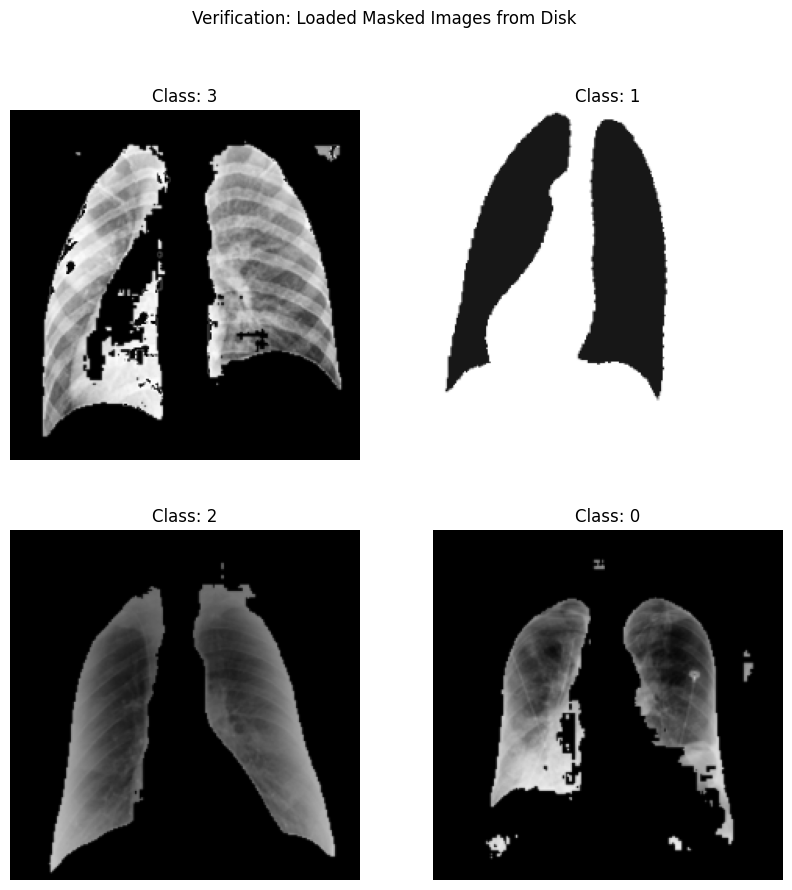

In [ ]:
import matplotlib.pyplot as plt

# Take one batch from the new dataset
for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(4):
        ax = plt.subplot(2, 2, i + 1)
        # Convert from 0-1 (if normalized) or show as is
        plt.imshow(images[i].numpy().astype("uint8") if images[i].numpy().max() > 1 else images[i])
        plt.title(f"Class: {np.argmax(labels[i])}")
        plt.axis("off")
    plt.suptitle("Verification: Loaded Masked Images from Disk")
    plt.show()


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

def check_for_black_images(root_dir):
    black_count = 0
    total_count = 0

    for subdir, dirs, files in os.walk(root_dir):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                total_count += 1
                img_path = os.path.join(subdir, file)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

                # Check if all pixels are 0
                if np.sum(img) == 0:
                    black_count += 1

    print(f"\nScan complete for: {root_dir}")
    print(f"Total images: {total_count}")
    print(f"Empty (black) images: {black_count}")
    print(f"Failure rate: {(black_count/total_count)*100:.2f}%")

# Run the check
check_for_black_images("masked_data/train")



Scan complete for: masked_data/train
Total images: 28000
Empty (black) images: 25
Failure rate: 0.09%


Found 28000 files belonging to 4 classes.


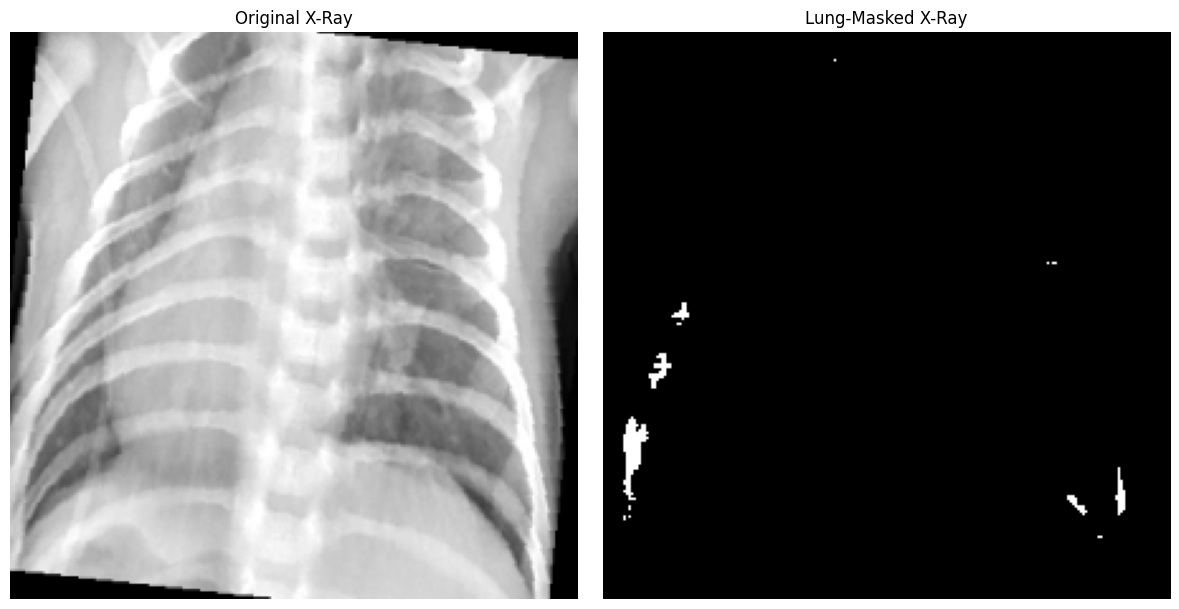

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Take a small batch from your existing training dataset
# Since your dataset is already mapped with lesion_focused_preprocess,
# it already contains the masked images.
# Let's pull from the raw directory loader to compare Original vs Masked.
raw_sample_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{SPLIT_DIR}/train",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=1,
    shuffle=True
)

# 2. Get one image
for images, labels in raw_sample_ds.take(1):
    original_img = images[0] / 255.0  # Normalize for display

    # 3. Manually apply your masking function to see the effect
    # Note: apply_lung_mask expects a single image tensor
    masked_img = apply_lung_mask(images[0])

    # 4. Plotting
    plt.figure(figsize=(12, 6))

    # Original Image
    plt.subplot(1, 2, 1)
    plt.imshow(original_img)
    plt.title("Original X-Ray")
    plt.axis('off')

    # Masked Image (Output of your U-Net pipeline)
    plt.subplot(1, 2, 2)
    plt.imshow(masked_img)
    plt.title("Lung-Masked X-Ray")
    plt.axis('off')

    plt.tight_layout()
    plt.show()


2.3: Augmentation layer

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.06),
    layers.RandomZoom(0.06),
    layers.RandomContrast(0.05),
])

print("Data augmentation layer defined successfully.")

Data augmentation layer defined successfully.


2.5: Build EfficientNetV2-B0 Model

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# 1. Get the list of all labels in your training set
# train_ds.class_names should be ['COVID', 'Lung_Opacity', 'Normal', 'Pneumonia']
train_labels = []
for images, labels in train_ds.unbatch():
    train_labels.append(np.argmax(labels.numpy()))

# 2. Calculate weights automatically
# This gives a higher 'weight' to classes with fewer images (like Viral/Pneumonia)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# 3. Convert to a dictionary for Keras
class_weight_dict = dict(enumerate(class_weights))

print("Class Weights Calculated:")
for i, weight in class_weight_dict.items():
    print(f"  Class {CLASSES[i]}: {weight:.2f}")

In [ ]:
base_model = EfficientNetV2B0(include_top=False, weights="imagenet", input_shape=(224,224,3))
base_model.trainable = False  # freeze first

inputs = layers.Input(shape=(224,224,3))
x = data_augmentation(inputs)
x = preprocess_input(x) # Wrap preprocess_input in a Lambda layer
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs)
model.summary()

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,924,436 (22.60 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

2.6: Compile model

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


2.7: Callbacks

In [ ]:
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-7
    verbose=1
)


2.8: Train model

In [ ]:
'''
steps_per_epoch = len(train_ds)//2
validation_steps = len(val_ds)//2

history = model.fit(
    train_ds,
    validation_data=val_ds,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    epochs=4,
    callbacks=[early_stop, checkpoint]
)
'''

'\nsteps_per_epoch = len(train_ds)//2\nvalidation_steps = len(val_ds)//2\n\nhistory = model.fit(\n    train_ds,\n    validation_data=val_ds,\n    steps_per_epoch=steps_per_epoch,\n    validation_steps=validation_steps,\n    epochs=4,\n    callbacks=[early_stop, checkpoint]\n)\n'

In [ ]:
EPOCHS_STAGE1 = 4  # train head
EPOCHS_STAGE2 = 8  # fine-tune

# Stage 1: Train only classifier head
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE1,
    class_weight=class_weight_dict,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

# Stage 2: Fine-tune tops layers
history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE2,
    class_weight=class_weight_dict,
    callbacks=[checkpoint, early_stop, reduce_lr]
)


Epoch 1/4
1749/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4424 - loss: 1.2227
Epoch 1: val_accuracy improved from -inf to 0.64833, saving model to best_model.keras
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 118s 57ms/step - accuracy: 0.4425 - loss: 1.2226 - val_accuracy: 0.6483 - val_loss: 0.8828 - learning_rate: 1.0000e-04
Epoch 2/4
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6368 - loss: 0.8839
Epoch 2: val_accuracy improved from 0.64833 to 0.68517, saving model to best_model.keras
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 87s 50ms/step - accuracy: 0.6368 - loss: 0.8839 - val_accuracy: 0.6852 - val_loss: 0.7860 - learning_rate: 1.0000e-04
Epoch 3/4
1749/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6654 - loss: 0.8104
Epoch 3: val_accuracy improved from 0.68517 to 0.70083, saving model to best_model.keras
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 87s 50ms/step - accuracy: 0.6654 - loss: 0.8104 - val_accuracy: 0.7008 - val_loss: 0.7430 - learning_rate: 1.0000e-04
Epoch 4/4
1750/1750 ━━━━

2.9: Plot training curves

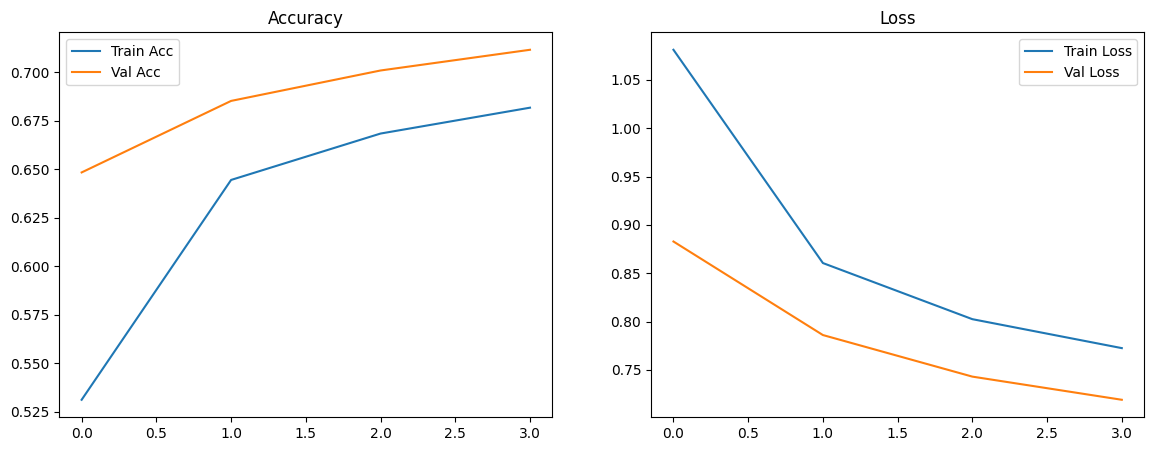

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss")
plt.legend()
plt.show()


2.10: Fine-Tune model

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weight_dict,
    callbacks=[checkpoint, early_stop, reduce_lr]
)


Epoch 1/10
1749/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6885 - loss: 0.7484
Epoch 1: val_accuracy did not improve from 0.73967
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 120s 59ms/step - accuracy: 0.6886 - loss: 0.7484 - val_accuracy: 0.7385 - val_loss: 0.6299 - learning_rate: 1.0000e-05
Epoch 2/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.7033 - loss: 0.7066
Epoch 2: val_accuracy improved from 0.73967 to 0.75850, saving model to best_model.keras
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 103s 59ms/step - accuracy: 0.7033 - loss: 0.7066 - val_accuracy: 0.7585 - val_loss: 0.5932 - learning_rate: 1.0000e-05
Epoch 3/10
1749/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.7178 - loss: 0.6727
Epoch 3: val_accuracy improved from 0.75850 to 0.76233, saving model to best_model.keras
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 141s 58ms/step - accuracy: 0.7178 - loss: 0.6726 - val_accuracy: 0.7623 - val_loss: 0.5784 - learning_rate: 1.0000e-05
Epoch 4/10
1749/1750 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

##**Evaluation**

In [ ]:
# Load best saved model (if not already in memory)
model = tf.keras.models.load_model("best_model.keras")

test_loss, test_acc = model.evaluate(test_ds)
print(f"✅ Test Accuracy: {test_acc:.4f}")
print(f"✅ Test Loss: {test_loss:.4f}")


375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 34ms/step - accuracy: 0.7085 - loss: 0.7086
✅ Test Accuracy: 0.7783
✅ Test Loss: 0.5515


In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=CLASSES))

              precision    recall  f1-score   support

      NORMAL       0.75      0.70      0.73      1500
       COVID       0.73      0.63      0.68      1500
       VIRAL       0.71      0.82      0.76      1500
   BACTERIAL       0.92      0.96      0.94      1500

    accuracy                           0.78      6000
   macro avg       0.78      0.78      0.78      6000
weighted avg       0.78      0.78      0.78      6000



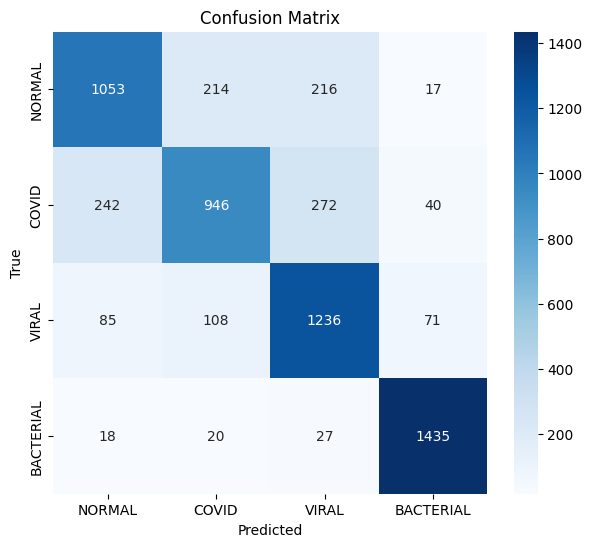

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score
y_true_ohe = tf.keras.utils.to_categorical(y_true, num_classes=len(CLASSES))
y_pred_proba = []
for images, labels in test_ds:
    y_pred_proba.extend(model.predict(images))

roc_auc = roc_auc_score(y_true_ohe, np.array(y_pred_proba), multi_class='ovo')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1

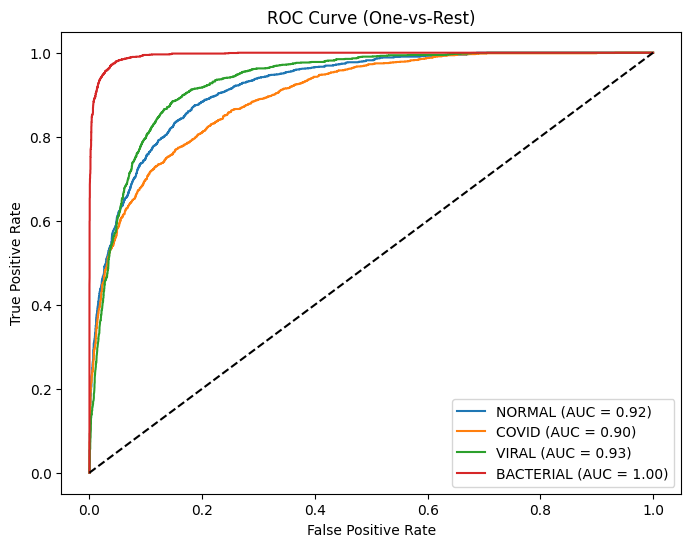

In [ ]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

for i, cls in enumerate(CLASSES):
    fpr, tpr, _ = roc_curve(y_true_ohe[:, i], np.array(y_pred_proba)[:, i])
    plt.plot(fpr, tpr, label=f"{cls} (AUC = {auc(fpr, tpr):.2f})")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-vs-Rest)")
plt.legend()
plt.show()


Calibration curve

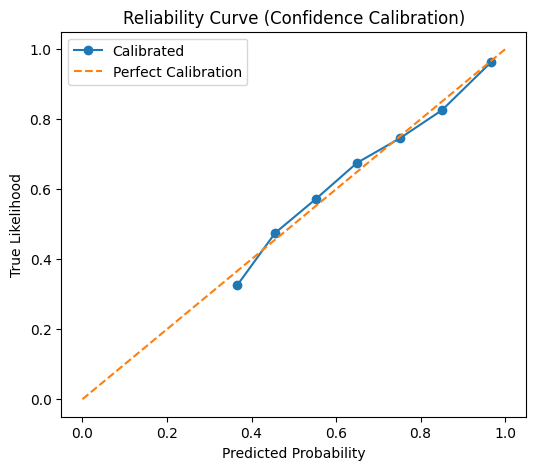

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Example: binary-style flattening for demonstration
y_true_flat = np.argmax(y_true_ohe, axis=1)
y_prob_flat = np.max(y_pred_proba, axis=1)

prob_true, prob_pred = calibration_curve((y_true_flat==y_pred), y_prob_flat, n_bins=10)

plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, marker='o', label='Calibrated')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect Calibration')
plt.xlabel('Predicted Probability')
plt.ylabel('True Likelihood')
plt.title('Reliability Curve (Confidence Calibration)')
plt.legend()
plt.show()

In [ ]:
# Confidence Distribution Histogram

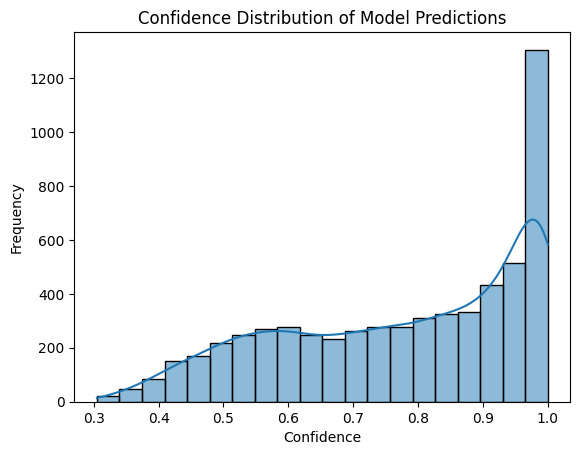

In [ ]:
import seaborn as sns

sns.histplot(y_prob_flat, bins=20, kde=True)
plt.title('Confidence Distribution of Model Predictions')
plt.xlabel('Confidence')
plt.ylabel('Frequency')
plt.show()


In [ ]:
import numpy as np


In [ ]:
def occlusion_sensitivity(model, image, label_index, patch_size=32, stride=16):
    """
    image: single image tensor (224,224,3), already preprocessed
    label_index: predicted class index
    """
    image = image.numpy()
    h, w, _ = image.shape
    heatmap = np.zeros((h, w))

    # Original prediction confidence
    original_pred = model.predict(image[np.newaxis, ...], verbose=0)[0]
    original_conf = original_pred[label_index]

    for y in range(0, h - patch_size, stride):
        for x in range(0, w - patch_size, stride):
            occluded = image.copy()
            occluded[y:y+patch_size, x:x+patch_size, :] = 0

            pred = model.predict(occluded[np.newaxis, ...], verbose=0)[0]
            drop = original_conf - pred[label_index]

            heatmap[y:y+patch_size, x:x+patch_size] = drop

    return heatmap


In [ ]:
import numpy as np

selected = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    confidences = np.max(preds, axis=1)
    pred_labels = np.argmax(preds, axis=1)
    true_labels = np.argmax(labels.numpy(), axis=1)

    for i in range(len(images)):
        selected.append({
            "image": images[i],
            "true": true_labels[i],
            "pred": pred_labels[i],
            "conf": confidences[i]
        })

# Sort by confidence (high → low)
selected = sorted(selected, key=lambda x: x["conf"], reverse=True)


In [ ]:

# Pick a high-confidence correct prediction
for item in selected:
    if item["true"] == item["pred"] and item["conf"] >= 0.85:
        test_image = item["image"]
        true_label = item["true"]
        pred_label = item["pred"]
        confidence = item["conf"]
        break


In [ ]:
heatmap = occlusion_sensitivity(
    model,
    test_image,
    pred_label,
    patch_size=32,
    stride=16
)


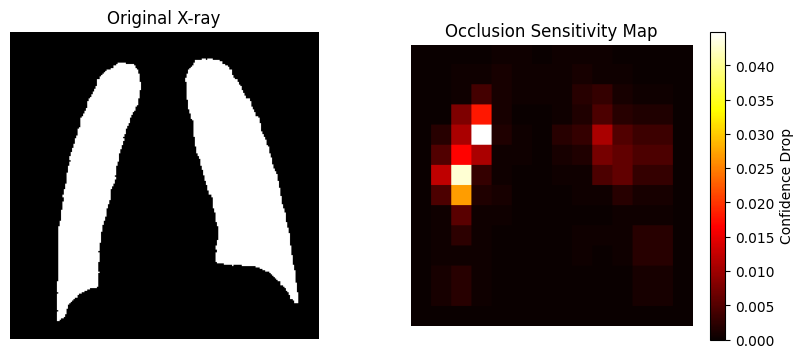

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(test_image.numpy())
plt.title("Original X-ray")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(heatmap, cmap="hot")
plt.title("Occlusion Sensitivity Map")
plt.colorbar(label="Confidence Drop")
plt.axis("off")

plt.show()


Misclassification analysis

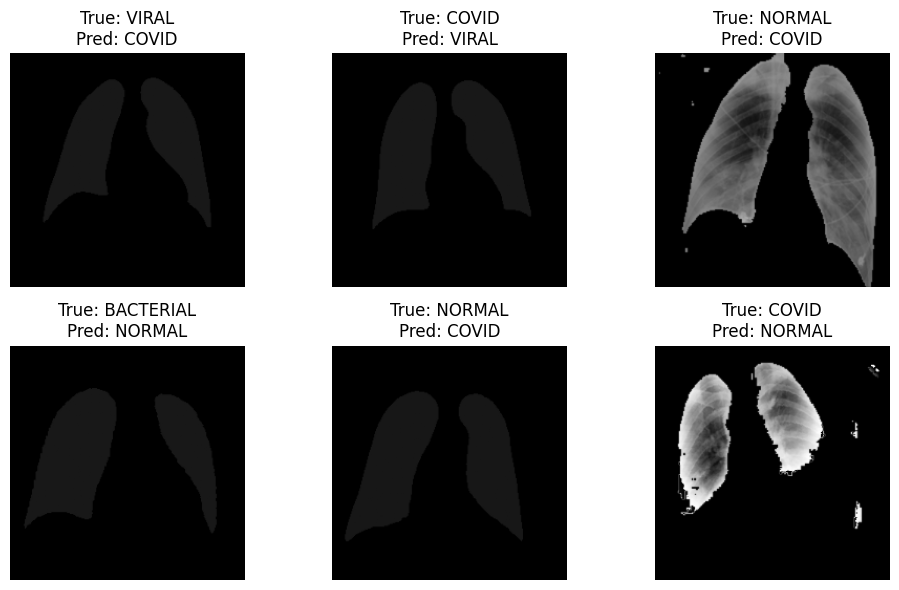

In [ ]:
import random
misclassified = np.where(y_true != y_pred)[0]

# Extract x_test from test_ds
x_test = []
for images, _ in test_ds:
    x_test.extend(images.numpy())
x_test = np.array(x_test)

# Unnormalize images if necessary for proper display
x_test = (x_test - x_test.min()) / (x_test.max() - x_test.min()) # Normalize to 0-1 range

samples = random.sample(list(misclassified), min(len(misclassified), 6))

plt.figure(figsize=(10, 6))
for i, idx in enumerate(samples):
    plt.subplot(2, 3, i+1)
    plt.imshow(x_test[idx])
    plt.title(f'True: {CLASSES[y_true[idx]]}\nPred: {CLASSES[y_pred[idx]]}')
    plt.axis('off')
plt.tight_layout()
plt.show()

t-SNE / PCA feature visualization

375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step


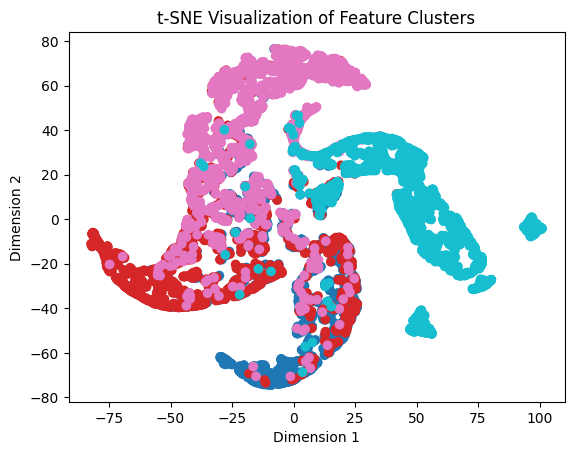

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

features = model.predict(test_ds)
tsne = TSNE(n_components=2, random_state=42)
embeddings = tsne.fit_transform(features)

plt.scatter(embeddings[:,0], embeddings[:,1], c=np.argmax(y_true_ohe, axis=1), cmap='tab10')
plt.title("t-SNE Visualization of Feature Clusters")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()

Precision–Recall Curves per Class

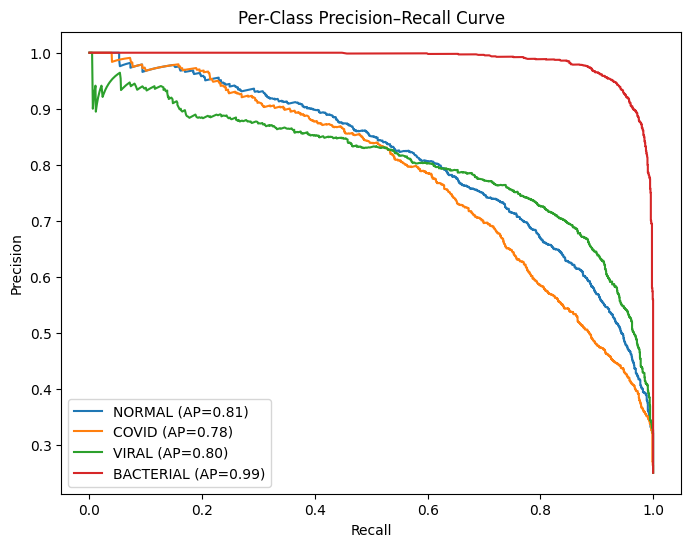

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8,6))
for i, cls in enumerate(CLASSES):
    precision, recall, _ = precision_recall_curve(y_true_ohe[:, i], np.array(y_pred_proba)[:, i])
    ap = average_precision_score(y_true_ohe[:, i], np.array(y_pred_proba)[:, i])
    plt.plot(recall, precision, label=f'{cls} (AP={ap:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Per-Class Precision–Recall Curve')
plt.legend()
plt.show()

# 4. **Confidence Caliberation**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import log_loss
from sklearn.calibration import calibration_curve

# --- 1. FIND OPTIMAL TEMPERATURE ---
print("Finding optimal temperature...")
val_logits = []
val_labels = []

# Extract raw logits (bypassing augmentation) from validation set
for imgs, labels in val_ds:
    # Logic to bypass augmentation layer (Layer 1)
    x = model.layers[2](imgs, training=False)
    for layer in model.layers[3:]:
        x = layer(x, training=False)
    val_logits.append(x.numpy())
    val_labels.append(np.argmax(labels.numpy(), axis=1))

val_logits = np.concatenate(val_logits)
val_labels = np.concatenate(val_labels)

# Search for the temperature that minimizes Log Loss
best_temp = 1.0
best_loss = float('inf')
for t in np.arange(0.5, 3.1, 0.1):
    probs = tf.nn.softmax(val_logits / t).numpy()
    loss = log_loss(val_labels, probs)
    if loss < best_loss:
        best_loss = loss
        best_temp = t

print(f"Optimal Temperature Found: {best_temp:.2f}")

# --- 2. DEFINE CALIBRATED MODEL & DECISION SUPPORT ---
def calibrate_model(model, temp):
    inputs = tf.keras.Input(shape=(224, 224, 3))
    # Bypass augmentation during inference
    x = model.layers[2](inputs, training=False)
    for layer in model.layers[3:]:
        x = layer(x, training=False)
    # Apply the found temperature
    calibrated_output = tf.keras.layers.Lambda(lambda x: x / temp)(x)
    return tf.keras.Model(inputs=inputs, outputs=calibrated_output)

def decision_support(probs, threshold=0.60):
    class_idx = np.argmax(probs)
    confidence = probs[class_idx]
    label = CLASSES[class_idx]

    if confidence < threshold:
        action = "Decision: LOW CONFIDENCE - Send to CT scan recommendation ⚠"
    elif label in ['COVID', 'Pneumonia'] and confidence < 0.80:
        action = "Decision: POTENTIAL INFECTION - Prioritize for Radiologist Review 🩺"
    else:
        action = f"Decision: High Confidence {label} - Standard Protocol ✅"
    return label, confidence, action

# Initialize the final pathway
calibrated_pathway = calibrate_model(model, best_temp)

# --- 3. PLOT CALIBRATION CURVE ---
def plot_calibration_results(logits, labels, temp, n_bins=10):
    plt.figure(figsize=(10, 6))

    # Uncalibrated (Temp = 1.0)
    uncal_probs = tf.nn.softmax(logits).numpy()
    # Calibrated (Temp = best_temp)
    cal_probs = tf.nn.softmax(logits / temp).numpy()

    # We plot the curve for the 'Positive' class (e.g., Pneumonia)
    # or an average across classes. Here we use the max predicted prob.
    y_true = np.eye(len(CLASSES))[labels].ravel()
    y_uncal = uncal_probs.ravel()
    y_cal = cal_probs.ravel()

    prob_true_uncal, prob_pred_uncal = calibration_curve(y_true, y_uncal, n_bins=n_bins)
    prob_true_cal, prob_pred_cal = calibration_curve(y_true, y_cal, n_bins=n_bins)

    plt.plot(prob_pred_uncal, prob_true_uncal, "s-", label="Uncalibrated", color='red')
    plt.plot(prob_pred_cal, prob_true_cal, "s-", label=f"Calibrated (T={temp:.2f})", color='green')
    plt.plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated")

    plt.ylabel("Fraction of Positives")
    plt.xlabel("Mean Predicted Probability")
    plt.title("Reliability Diagram: Model Confidence vs. Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_calibration_results(val_logits, val_labels, best_temp)
print("Calibration module and plots completed.")

In [ ]:
# --- THE FINAL INFERENCE CELL ---
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

# 1. Path to the image you want to test
# Replace this with any image path you want to check
test_img_path = "/content/bacterial p.jpg"

# 2. Load and Apply the Lung Mask
# This ensures we only look at the lung area, just like during training
img = tf.keras.utils.load_img(test_img_path, target_size=(224, 224))
img_array = tf.keras.utils.img_to_array(img)
masked_array = apply_lung_mask(img_array)

# 3. Manual Normalization (Brings range to 0.0 - 1.0)
normalized_array = masked_array / 255.0
input_tensor = np.expand_dims(normalized_array, axis=0)

# 4. Predict using the Calibrated Pathway
# This uses the 'best_temp' and skips the augmentation layer automatically
calibrated_logits = calibrated_pathway.predict(input_tensor)

# 5. Convert Logits to Probabilities (Softmax)
final_probs = tf.nn.softmax(calibrated_logits).numpy()[0]

# 6. Get the Label and Clinical Recommendation
label, confidence, action = decision_support(final_probs)

# --- DISPLAY RESULTS ---
print(f"Verified Input Range: {np.min(normalized_array):.2f} to {np.max(normalized_array):.2f}")
print("-" * 30)
print(f"PREDICTION: {label}")
print(f"CONFIDENCE: {confidence:.4f}")
print(f"ACTION: {action}")
print("-" * 30)

# 7. Visual Check: See what the model actually "saw"
plt.figure(figsize=(6,6))
plt.imshow(normalized_array)
plt.title(f"Model Input: {label} ({confidence:.2%})")
plt.axis('off')
plt.show()

In [ ]:
from google.colab import files

files.download('best_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>